In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [17]:
data=pd.read_csv("T.dat", delim_whitespace=True)

/tmp/ipykernel_41149/4206447503.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data=pd.read_csv("T.dat", delim_whitespace=True)


In [18]:
data

,Material,T_exp,T_MC,T_MC*,S,Error
0,Ba2NiWO6,48.0,23.0,46.0,1.0,4.20
1,BaMn2As2,625.0,460.0,644.0,2.5,3.04
2,BaMn2Bi2,387.2,238.0,333.2,2.5,13.90
3,BaNi2As2O8,18.5,11.0,22.0,1.0,18.90
4,Bi2CuO4,50.0,17.5,52.5,0.5,5.00
...,...,...,...,...,...,...
67,YbMnBi2,290.0,203.0,284.2,2.5,2.00
68,YbMnSb2,345.0,266.0,372.4,2.5,7.94
69,YFeO3,644.5,445.0,623.0,2.5,3.30
70,YMnO3,70.0,40.0,60.0,2.0,14.30


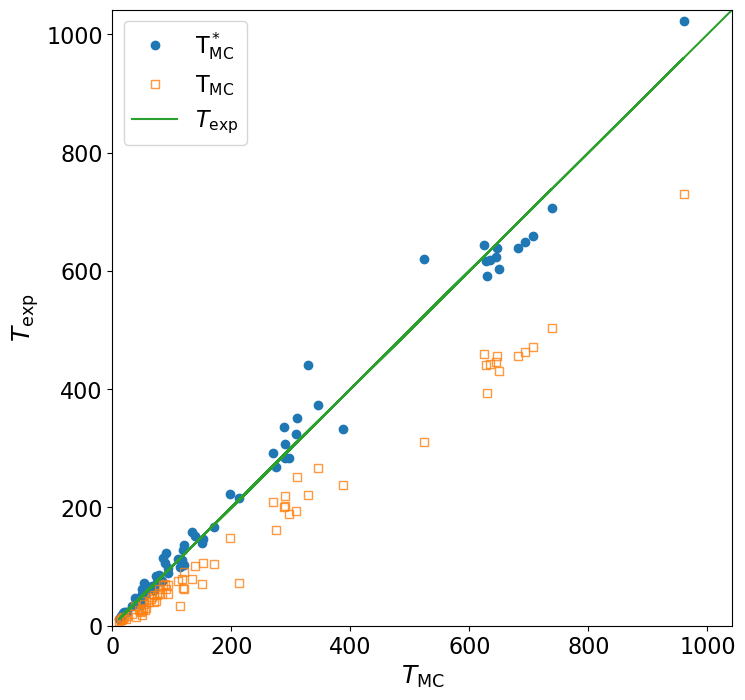

In [19]:
texp=data["T_exp"]
tmc=data["T_MC"]
tmc_cor=data["T_MC*"]
xideal=data["T_exp"]
fig, ax = plt.subplots(figsize =(8, 8))
plt.xticks([0,200,400,600,800,1000])
plt.plot(texp, tmc_cor,'o', label=r'T$_{\mathrm{MC}}^*$') 
plt.plot(texp, tmc, 's', alpha=0.8,markerfacecolor='none', label=r'T$_{\mathrm{MC}}$')
Tmax=max(texp.max(), tmc.max(), tmc_cor.max())
Texp=np.array(texp)
Texpnew=np.append(texp, Tmax+20)
plt.plot(Texpnew, Texpnew, label=r'$T_{\mathrm{exp}}$')
plt.xlim(0,Tmax+20)
plt.ylim(0,Tmax+20)
plt.xlabel(r'$T_{\mathrm{MC}}$',fontsize=18)
plt.ylabel(r'$T_{\mathrm{exp}}$',fontsize=18)
plt.legend(fontsize=16)
# Increase font sizes
plt.xticks(fontsize=16)  # Increase x-axis tick font size
plt.yticks(fontsize=16)  # Increase y-axis tick font size

plt.savefig("T.pdf")

In [20]:
#some checking
ape_tmc_cor=abs(tmc_cor-texp)/texp*100
j=0
for i in data["Error"]:
    if abs( data["Error"].values[j]-ape_tmc_cor[j] ) > 0.1:
        print(data["Material"][j], data["Error"].values[j]-ape_tmc_cor[j])
    j=j+1

In [21]:
#some checking
tmc_cor1=data["T_MC"]*(data["S"]+1.0)/data["S"]
j=0
for i in data["T_MC*"]:
    if abs(data["T_MC*"].values[j]-tmc_cor1[j]) > 0.1:
        print(data["Material"][j], data["T_MC*"].values[j], tmc_cor1[j])
    j=j+1

In [22]:
mask15=data["Error"]> 15
data[mask15]

,Material,T_exp,T_MC,T_MC*,S,Error
3,BaNi2As2O8,18.5,11.0,22.00,1.0,18.90
7,CaMn2Sb2,85.0,69.0,115.00,1.5,35.30
8,CaMn7O12,90.0,61.0,122.00,1.0,35.50
10,CoO,289.0,201.0,335.00,1.5,15.90
11,CoPS3,120.0,61.0,101.66,1.5,15.30
17,CrCl3,14.0,10.0,16.60,1.5,18.60
32,KCuF3,39.0,15.0,45.00,0.5,15.40
34,La2NiO4,328.0,220.0,440.00,1.0,34.10
38,LiFePO4,50.0,41.0,61.50,2.0,23.00
39,LuMnO3,87.5,71.0,106.50,2.0,21.70


In [23]:
mask5=data["Error"] <5
data[mask5]
len(data[mask5])/len(data["Error"])*100

36.11111111111111

In [24]:
mask5_10 = (data["Error"] >= 5) & (data["Error"] < 10)
len(data[mask5_10])/len(data["Error"])*100

31.944444444444443

In [25]:
mask10_15 = (data["Error"] >= 10) & (data["Error"] <= 15)
len(data[mask10_15])/len(data["Error"])*100

11.11111111111111

In [26]:
mask15 = data["Error"] > 15
len(data[mask15])/len(data["Error"])*100

20.833333333333336

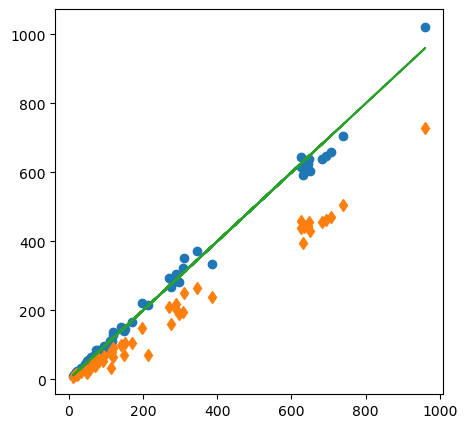

In [27]:
mask_l15=data["Error"]< 15
data[mask_l15]
texp=data[mask_l15]["T_exp"]
tmc=data[mask_l15]["T_MC"]
tmc_cor=data[mask_l15]["T_MC*"]
xideal=data[mask_l15]["T_exp"]
fig, ax = plt.subplots(figsize =(5, 5))
plt.plot(texp, tmc_cor,'o') 
plt.plot(texp, tmc, 'd')
plt.plot(texp, texp)

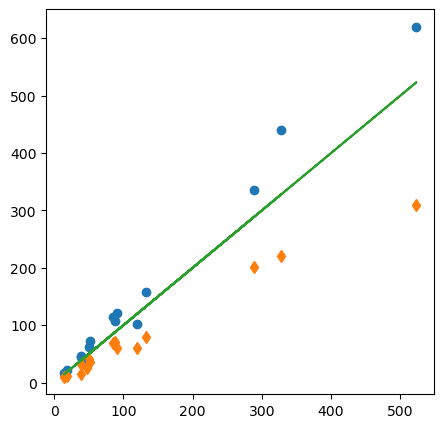

In [28]:
mask_l15g=data["Error"]> 15
data[mask_l15g]
texp=data[mask_l15g]["T_exp"]
tmc=data[mask_l15g]["T_MC"]
tmc_cor=data[mask_l15g]["T_MC*"]
xideal=data[mask_l15g]["T_exp"]
fig, ax = plt.subplots(figsize =(5, 5))
plt.plot(texp, tmc_cor,'o') 
plt.plot(texp, tmc, 'd')
plt.plot(texp, texp)

In [29]:
data["Error"].mean()

9.615694444444443

In [30]:
error_Tmc=abs(data["T_exp"]-data["T_MC"])/data["T_exp"]*100

In [31]:
error_Tmc.mean()

35.07164690880565

In [32]:
error_Tmc_corr=abs(data["T_exp"]-data["T_MC*"])/data["T_exp"]*100
error_Tmc_corr.mean()

9.617041708736089